In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize, curve_fit
from emcee import EnsembleSampler

import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel(r"Bell's Inequality Data.xlsx", "Tau")
df['Actual Counts'] = df['Coincident Counts'] * 1000
df

,Dial Tau,Actual Tau?,Coincident Counts,Actual Counts
0,45.0,-7.00,0.093,93.0
1,46.0,-5.60,0.086,86.0
2,47.0,-4.20,0.082,82.0
3,48.0,-2.80,0.064,64.0
4,49.0,-1.40,0.080,80.0
...,...,...,...,...
61,52.0,2.80,1.677,1677.0
62,52.2,3.08,1.717,1717.0
63,52.4,3.36,1.842,1842.0
64,52.6,3.64,2.015,2015.0


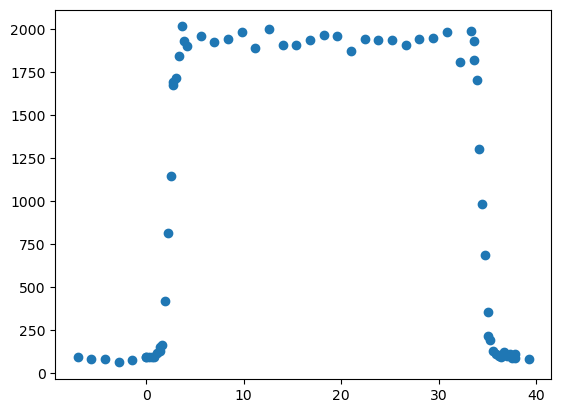

In [3]:
plt.scatter(df['Actual Tau?'], df['Actual Counts'])

In [4]:
def step_model(x, tau, delta, background, amplitude):
    x = np.array(x)
    y = background * np.ones_like(x)
    y[np.abs(x - tau) < delta] += amplitude
    return y

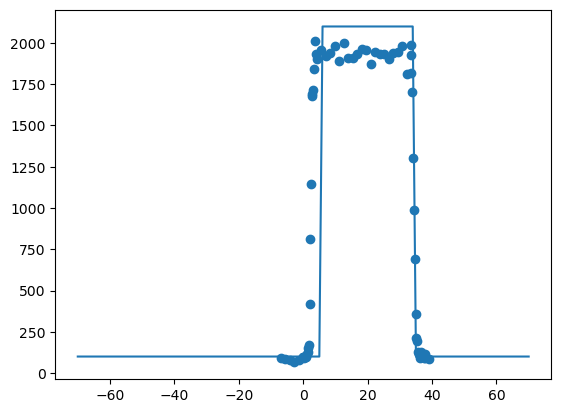

In [5]:
x = np.linspace(-70, 70, 141)
y = step_model(x, 20, 15, 100, 2000)
plt.plot(x, y)
plt.scatter(df['Actual Tau?'], df['Actual Counts'])

In [6]:
def loss(theta, log = True):
    if log:
        theta = np.exp(theta)
    y_mod = step_model(df["Actual Tau?"], *theta)
    y_data = df["Actual Counts"]
    return np.sum((y_data - y_mod)**2/y_data)

In [7]:
loss(np.log([20, 15, 100, 2000]))

np.float64(18748.862432677637)

In [8]:
opt_res = minimize(loss, np.log([20, 15, 100, 1900]), method="Nelder-Mead")

# opt_res.x = np.exp(opt_res.x)
opt_res

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 3305.4556721355184
             x: [ 2.906e+00  2.768e+00  4.781e+00  7.446e+00]
           nit: 69
          nfev: 128
 final_simplex: (array([[ 2.906e+00,  2.768e+00,  4.781e+00,  7.446e+00],
                       [ 2.906e+00,  2.768e+00,  4.780e+00,  7.446e+00],
                       ...,
                       [ 2.906e+00,  2.768e+00,  4.781e+00,  7.446e+00],
                       [ 2.906e+00,  2.768e+00,  4.781e+00,  7.446e+00]],
                      shape=(5, 4)), array([ 3.305e+03,  3.305e+03,  3.305e+03,  3.305e+03,
                        3.305e+03]))

(-20.0, 50.0)

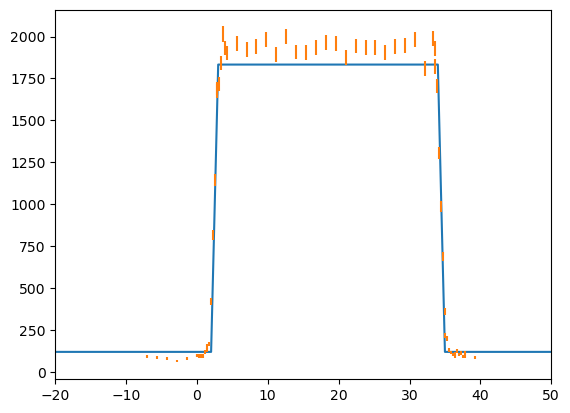

In [9]:
x = np.linspace(-70, 70, 141)
y = step_model(x, *np.exp(opt_res.x))
plt.plot(x, y)
plt.errorbar(df['Actual Tau?'], df['Actual Counts'], np.sqrt(df['Actual Counts']), ls="")
plt.xlim(-20, 50)

In [10]:
y

array([ 119.16882131,  119.16882131,  119.16882131,  119.16882131,
        119.16882131,  119.16882131,  119.16882131,  119.16882131,
        119.16882131,  119.16882131,  119.16882131,  119.16882131,
        119.16882131,  119.16882131,  119.16882131,  119.16882131,
        119.16882131,  119.16882131,  119.16882131,  119.16882131,
        119.16882131,  119.16882131,  119.16882131,  119.16882131,
        119.16882131,  119.16882131,  119.16882131,  119.16882131,
        119.16882131,  119.16882131,  119.16882131,  119.16882131,
        119.16882131,  119.16882131,  119.16882131,  119.16882131,
        119.16882131,  119.16882131,  119.16882131,  119.16882131,
        119.16882131,  119.16882131,  119.16882131,  119.16882131,
        119.16882131,  119.16882131,  119.16882131,  119.16882131,
        119.16882131,  119.16882131,  119.16882131,  119.16882131,
        119.16882131,  119.16882131,  119.16882131,  119.16882131,
        119.16882131,  119.16882131,  119.16882131,  119.16882

In [11]:
param_labels = ["tau", "delta", "background", "amplitude", "pow"]
for label, val in zip(param_labels, opt_res.x):
    print(f"{label}: {val:.3f}")

tau: 2.906
delta: 2.768
background: 4.781
amplitude: 7.446


In [12]:
print("Actual physical parameters:")
param_labels = ["tau", "delta", "background", "amplitude"]
for label, val in zip(param_labels, np.exp(opt_res.x)):
    print(f"{label}: {val:.3f}")

Actual physical parameters:
tau: 18.291
delta: 15.919
background: 119.169
amplitude: 1713.541


In [13]:
def log_prior(theta):
    if np.any(theta < 0):
        return -np.inf
    
    return 0

def log_prob(theta):
    if log_prior(theta) == -np.inf:
        return -np.inf
    
    return -loss(theta, log=False)

In [14]:
N_WALKERS = 10

In [15]:
BUMP_SIZE = 1
x0 = np.exp(opt_res.x) + BUMP_SIZE * np.random.randn(N_WALKERS, len(opt_res.x))
x0

array([[  17.99578792,   17.67431076,  119.24392943, 1714.80061689],
       [  19.78910862,   13.85581815,  118.54736648, 1713.88708287],
       [  19.1368509 ,   16.04192374,  117.77997207, 1712.95914769],
       [  17.9235854 ,   16.14663937,  118.34141521, 1713.48171036],
       [  17.95432372,   15.04523991,  120.93223769, 1714.37201732],
       [  18.05980848,   14.54199512,  119.36685037, 1711.38590865],
       [  17.79923745,   16.62619609,  119.4391176 , 1713.16229139],
       [  17.79436736,   15.39408626,  119.18335412, 1712.6710274 ],
       [  17.056964  ,   17.92317787,  119.56188532, 1713.32388248],
       [  17.13615019,   16.17386686,  117.93846188, 1713.82373485]])

In [16]:
sampler = EnsembleSampler(10, len(opt_res.x), log_prob)
sampler.run_mcmc(x0, 100_000, progress=True)

100%|██████████| 100000/100000 [03:58<00:00, 418.67it/s]


State([[  18.42668271   16.04109545  117.9358679  1663.5629181 ]
 [  18.47101657   16.08069439  115.13896792 1679.20388873]
 [  18.48536043   16.03317726  117.37163223 1669.08085274]
 [  18.45816813   16.12763059  115.93496193 1674.36556038]
 [  18.410737     16.13437234  117.5848042  1670.40575762]
 [  18.38199387   16.12713195  114.43281245 1677.70334034]
 [  18.44167427   16.15202276  115.09069482 1677.2480141 ]
 [  18.41399089   16.10874609  116.69436277 1667.28378105]
 [  18.47789229   16.0095049   115.9574935  1670.31681667]
 [  18.4986858    16.07410951  115.92307307 1676.13910593]], log_prob=[-3233.84711659 -3233.22406219 -3232.67455974 -3232.27790549
 -3232.83890117 -3233.20079784 -3232.79630769 -3232.48864116
 -3232.14601445 -3232.52971265], blobs=None, random_state=('MT19937', array([1248126911, 2470673175, 2989047340, 2238309684, 1911495838,
       2908693410, 2224545394, 1679207450,  761359458, 1255507640,
       3867703924, 4081066960, 2424521828, 1357429276, 3104419205,


KeyboardInterrupt: 

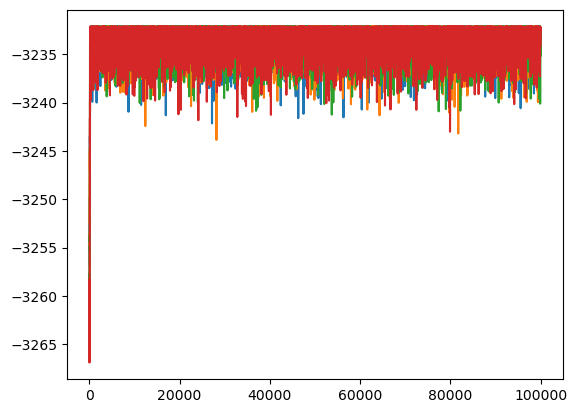

In [17]:
chain = sampler.get_chain(discard=100)
for walker_n in range(chain.shape[1]):
    y = []
    for sample_n in range(chain.shape[0]):
        y.append(log_prob(chain[sample_n, walker_n, :]))
    plt.plot(y)

# plt.yscale("log")

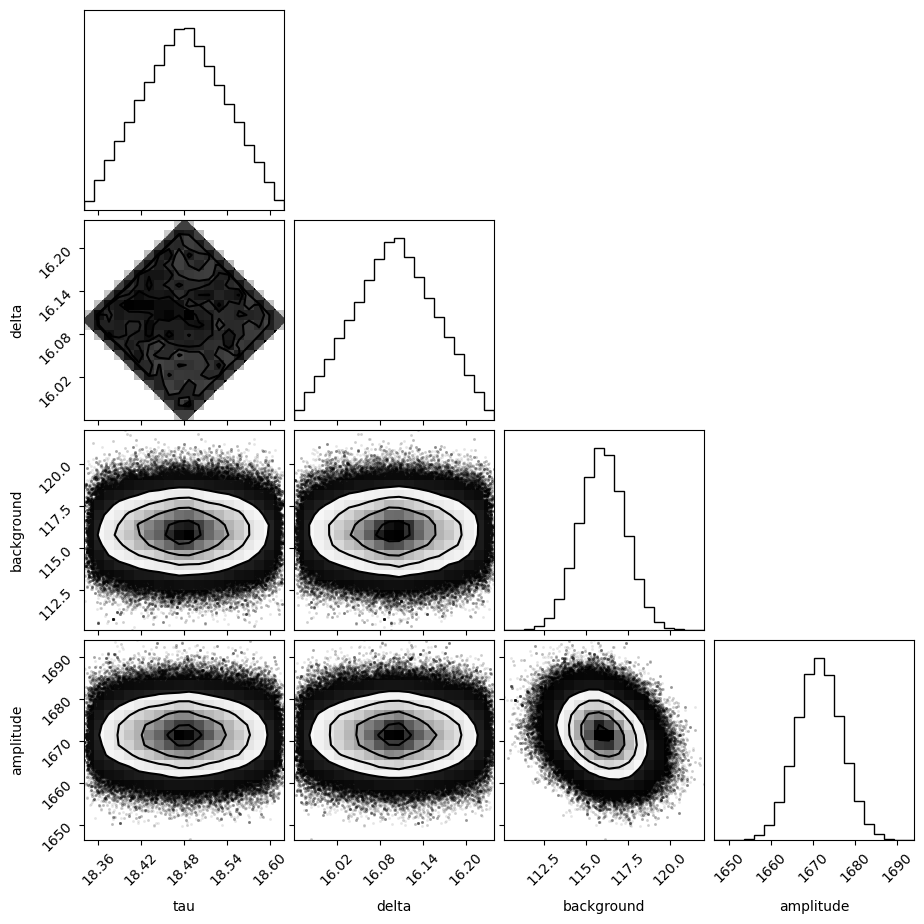

In [18]:
import corner

corner.corner(sampler.get_chain(discard=1000, flat=True), labels=param_labels);

In [23]:
np.sqrt(np.diag(np.cov(sampler.get_chain(flat=True, discard=100).T))) * 2

array([ 0.11427505,  0.11325533,  2.69821405, 10.90525431])

do note the funky diamond shape in the tau-delta plot. i think it happens because if you push delta past a certain point you suddenly put the top of the step above a point that is nowhere near it, so it becomes a way worse fit and thus doesn't get sampled. and you can make up for it by shrinking the width (delta) but only to the point that it doesn't screw with the points on the other side.

so i argue that we shouldn't use these values for the uncertainty in tau or delta and instead just use 2x the space between any two points and call it a day.